## Import liblary

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
pd.set_option('display.max_columns', None)

## Data Loading

In [10]:
df = pd.read_csv('/content/cleaned_data.csv')

In [11]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,previous_contact,pdays_clean
0,59,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1,No Previous Contact,NaN
1,56,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,1,No Previous Contact,NaN
2,41,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,1,No Previous Contact,NaN
3,55,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,1,No Previous Contact,NaN
4,54,admin.,married,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,unknown,1,No Previous Contact,NaN


## Basic Explorations

In [12]:
df.shape

(11162, 19)

In [13]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit', 'previous_contact', 'pdays_clean'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               11162 non-null  int64  
 1   job               11162 non-null  object 
 2   marital           11162 non-null  object 
 3   education         11162 non-null  object 
 4   default           11162 non-null  int64  
 5   balance           11162 non-null  int64  
 6   housing           11162 non-null  int64  
 7   loan              11162 non-null  int64  
 8   contact           11162 non-null  object 
 9   day               11162 non-null  int64  
 10  month             11162 non-null  object 
 11  duration          11162 non-null  int64  
 12  campaign          11162 non-null  int64  
 13  pdays             11162 non-null  int64  
 14  previous          11162 non-null  int64  
 15  poutcome          11162 non-null  object 
 16  deposit           11162 non-null  int64 

In [15]:
missing = pd.DataFrame(
    df.isnull().sum(),
    columns=['Missing Values']
)

missing[
    missing['Missing Values'] > 0
]

,Missing Values
pdays_clean,8324


In [16]:
print(
    'Duplicate rows:',
    df.duplicated().sum()
)

Duplicate rows: 0


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0
default,11162.0,0.015051,0.121761,0.0,0.0,0.0,0.00,1.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
housing,11162.0,0.473123,0.499299,0.0,0.0,0.0,1.00,1.0
loan,11162.0,0.130801,0.337198,0.0,0.0,0.0,0.00,1.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0


In [18]:
df.describe(include='object').T

,count,unique,top,freq
job,11162,12,management,2566
marital,11162,3,married,6351
education,11162,4,secondary,5476
contact,11162,3,cellular,8042
month,11162,12,may,2824
poutcome,11162,4,unknown,8326
previous_contact,11162,2,No Previous Contact,8324


## Univariate Analysis

In [19]:
numerical_cols = [
    'age',
    'balance',
    'duration',
    'campaign',
    'previous',
    'pdays_clean'
]

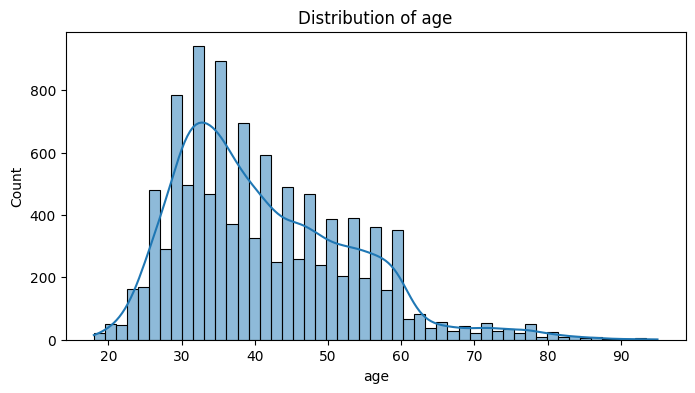

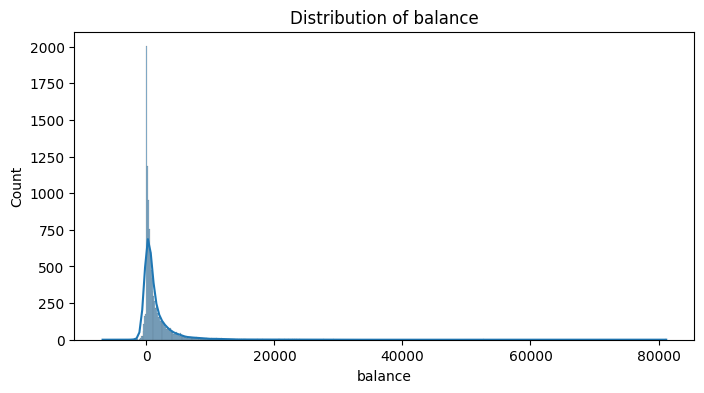

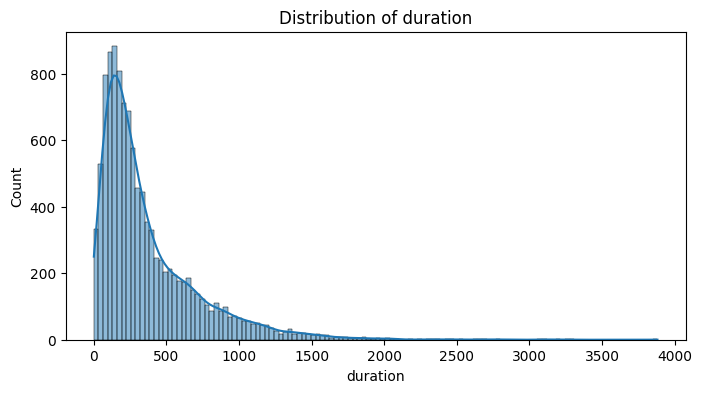

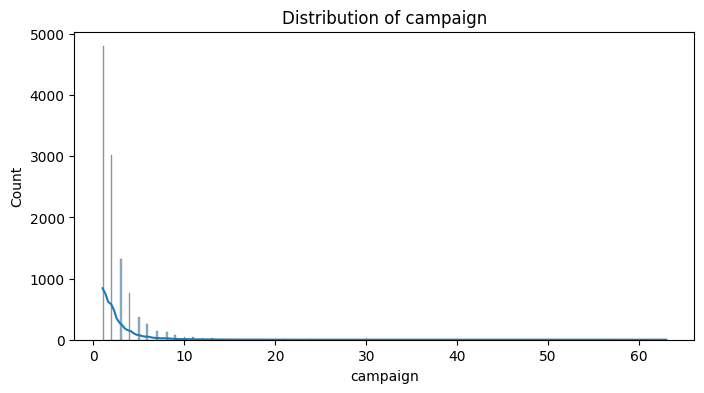

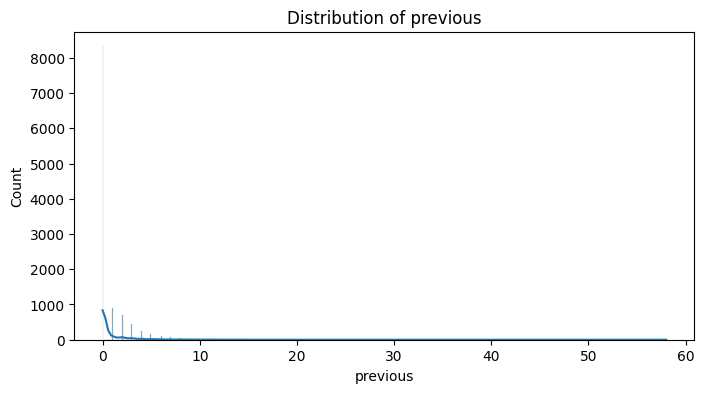

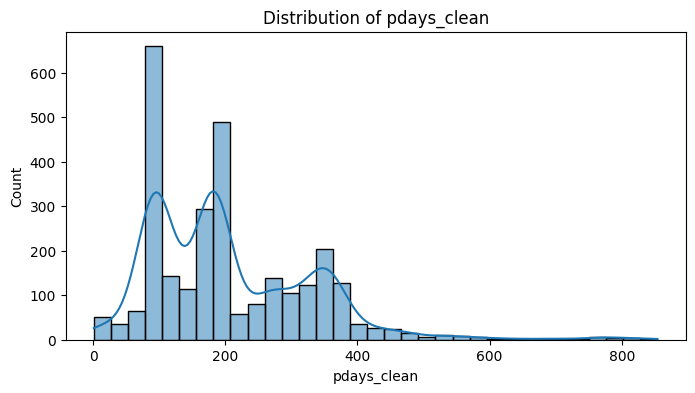

In [20]:
for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(
        f'Distribution of {col}'
    )

    plt.show()

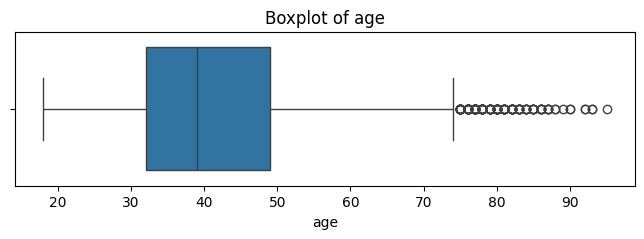

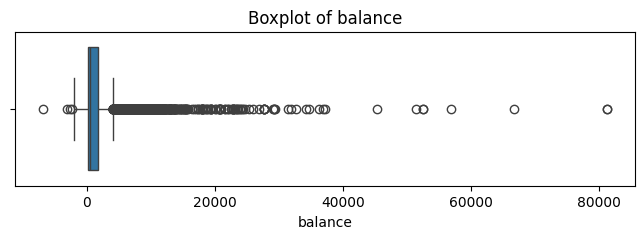

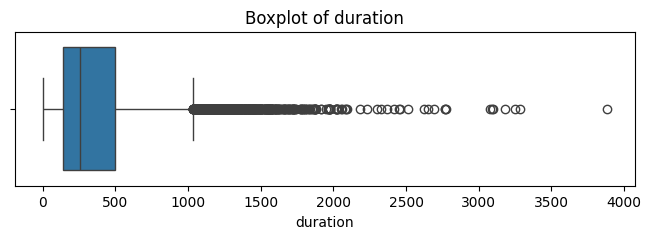

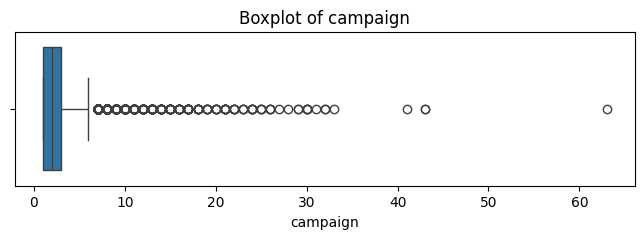

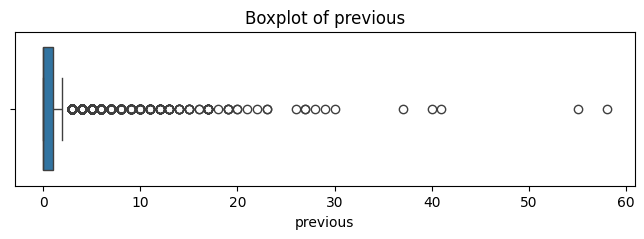

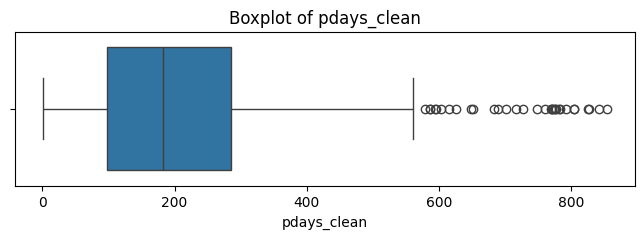

In [21]:
for col in numerical_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(
        f'Boxplot of {col}'
    )

    plt.show()

In [22]:
categorical_cols = [
    'job',
    'marital',
    'education',
    'contact',
    'month',
    'poutcome',
    'previous_contact'
]

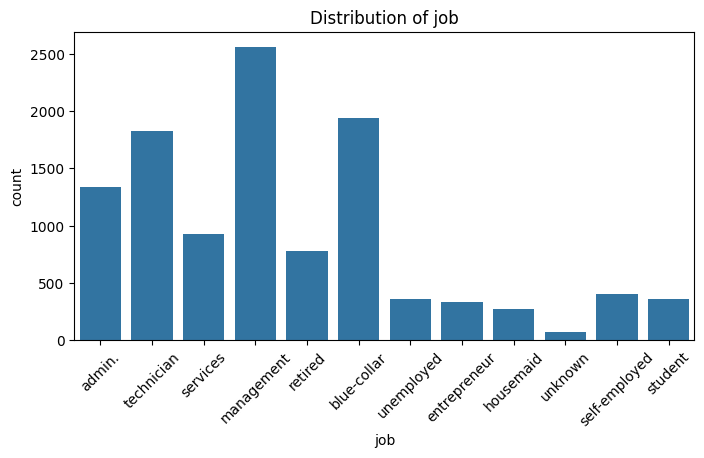

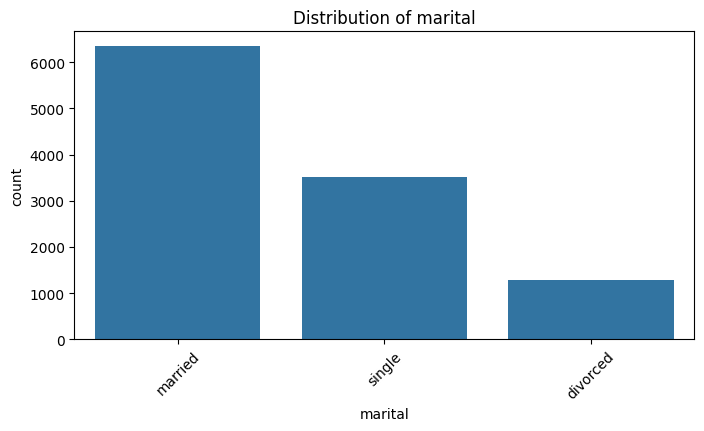

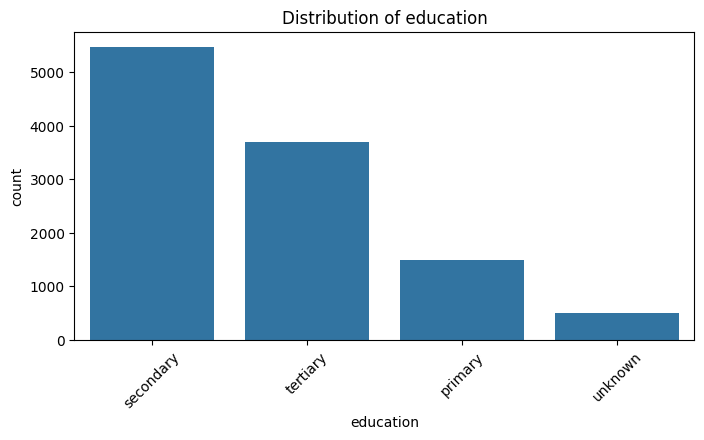

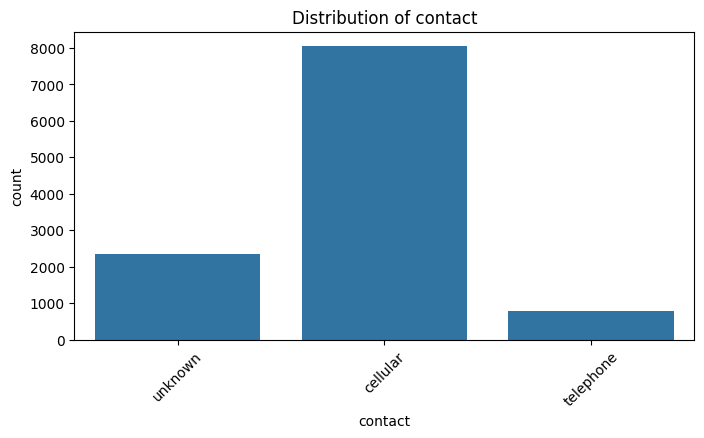

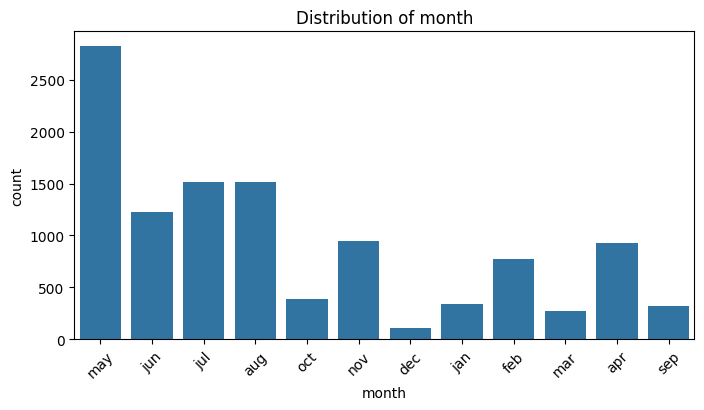

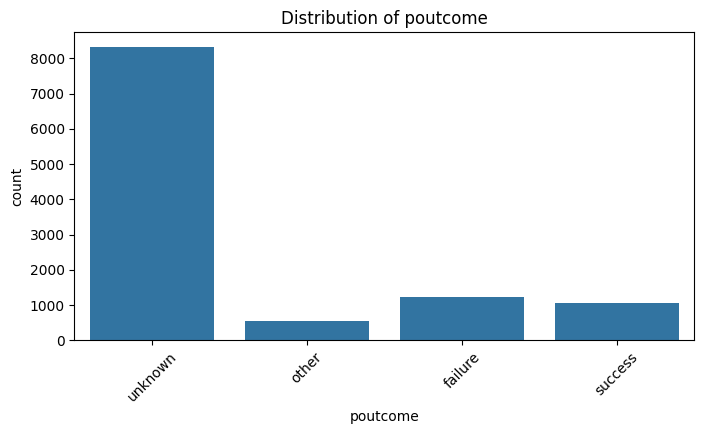

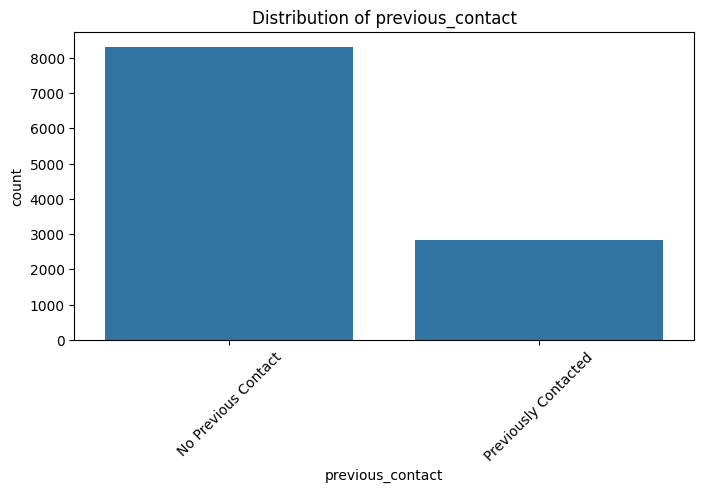

In [23]:
for col in categorical_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col
    )

    plt.title(
        f'Distribution of {col}'
    )

    plt.xticks(rotation=45)

    plt.show()

In [24]:
for col in categorical_cols:

    print('\n')
    print(col.upper())

    print(
        round(
            df[col]
            .value_counts(normalize=True)
            *100,
            2
        )
    )



JOB
job
management       22.99
blue-collar      17.42
technician       16.33
admin.           11.95
services          8.27
retired           6.97
self-employed     3.63
student           3.23
unemployed        3.20
entrepreneur      2.94
housemaid         2.45
unknown           0.63
Name: proportion, dtype: float64


MARITAL
marital
married     56.90
single      31.52
divorced    11.58
Name: proportion, dtype: float64


EDUCATION
education
secondary    49.06
tertiary     33.05
primary      13.44
unknown       4.45
Name: proportion, dtype: float64


CONTACT
contact
cellular     72.05
unknown      21.02
telephone     6.93
Name: proportion, dtype: float64


MONTH
month
may    25.30
aug    13.61
jul    13.56
jun    10.95
nov     8.45
apr     8.27
feb     6.95
oct     3.51
jan     3.08
sep     2.86
mar     2.47
dec     0.99
Name: proportion, dtype: float64


POUTCOME
poutcome
unknown    74.59
failure    11.00
success     9.60
other       4.81
Name: proportion, dtype: float64


PREVIOUS_CO

## Bivariate analysis

In [25]:
for col in numerical_cols:

    print('\n')
    print(col.upper())

    print(
        df.groupby(
            'deposit'
        )[col]
        .mean()
    )



AGE
deposit
0    40.837391
1    41.670070
Name: age, dtype: float64


BALANCE
deposit
0    1280.227141
1    1804.267915
Name: balance, dtype: float64


DURATION
deposit
0    223.130257
1    537.294574
Name: duration, dtype: float64


CAMPAIGN
deposit
0    2.839264
1    2.141047
Name: campaign, dtype: float64


PREVIOUS
deposit
0    0.528350
1    1.170354
Name: previous, dtype: float64


PDAYS_CLEAN
deposit
0    229.924973
1    192.521785
Name: pdays_clean, dtype: float64


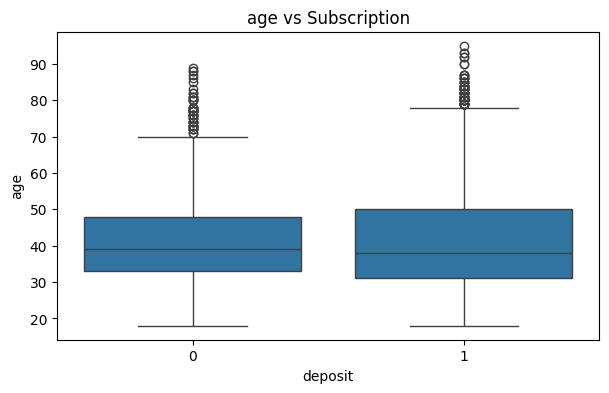

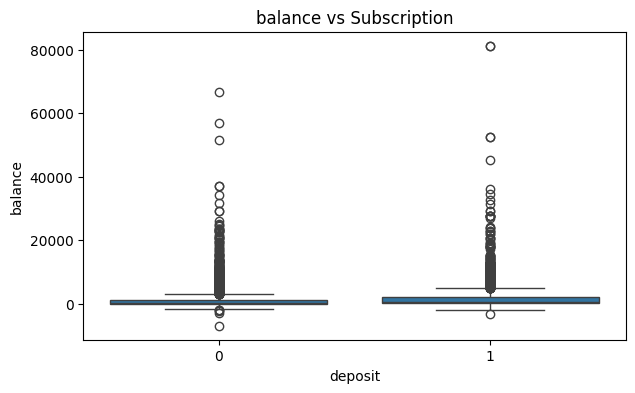

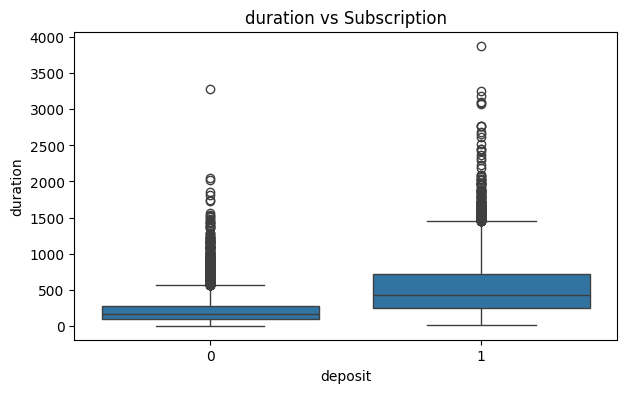

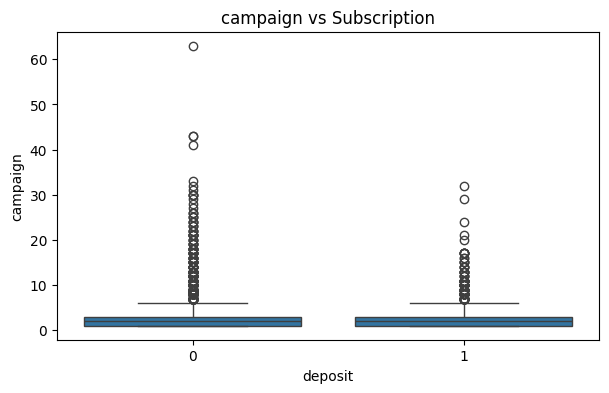

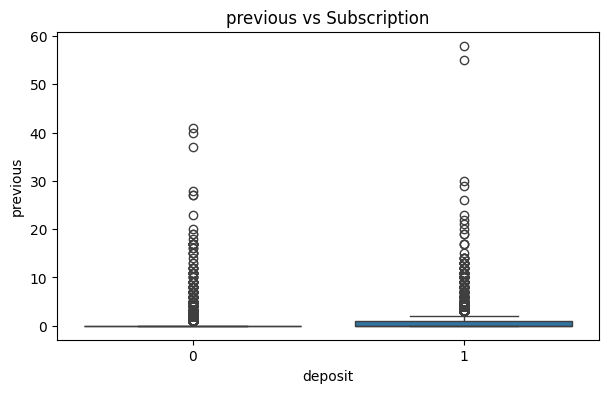

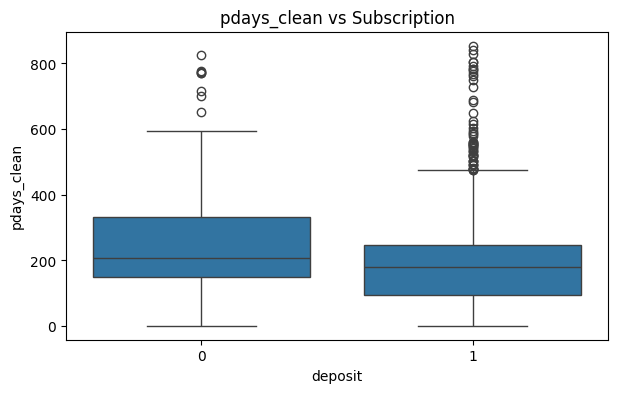

In [26]:
for col in numerical_cols:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        x='deposit',
        y=col
    )

    plt.title(
        f'{col} vs Subscription'
    )

    plt.show()

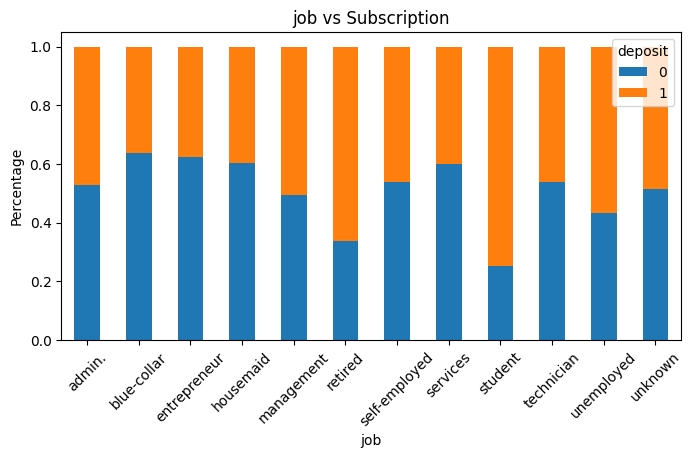

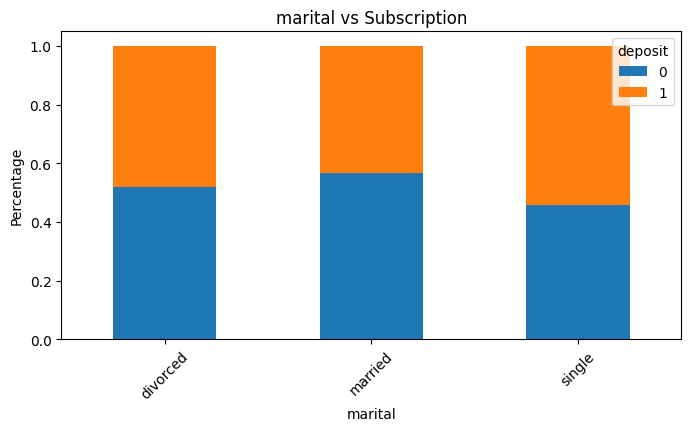

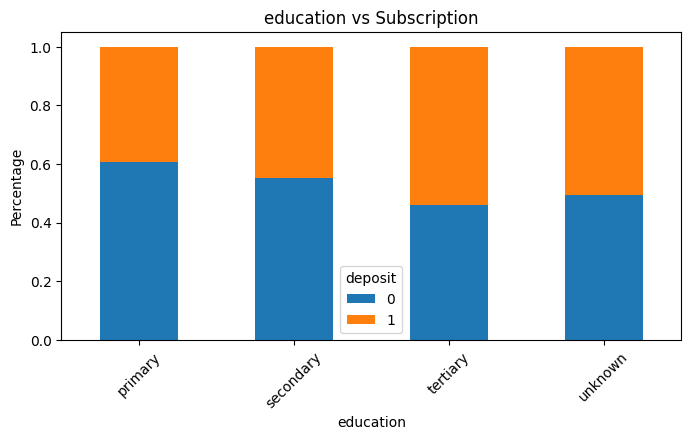

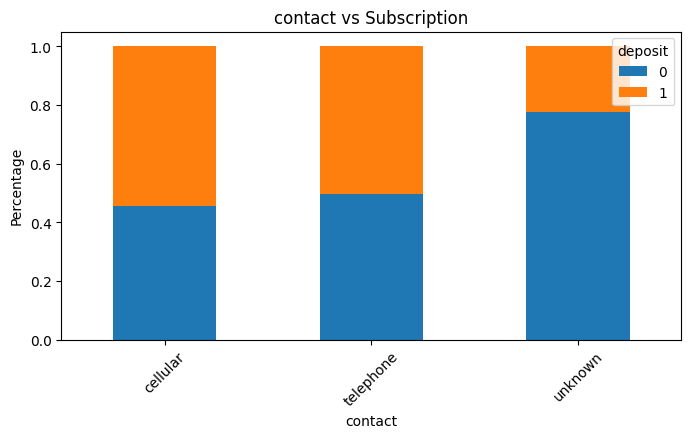

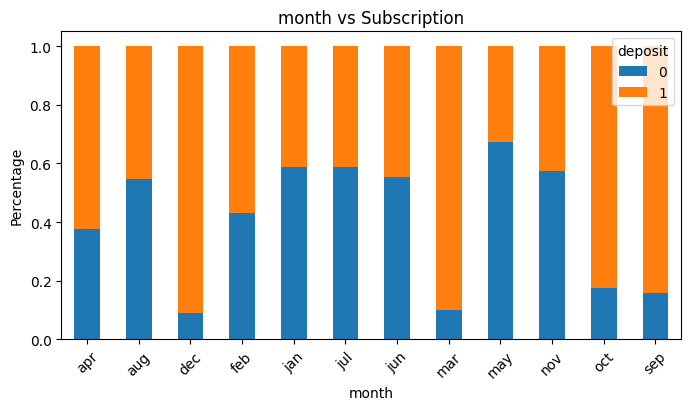

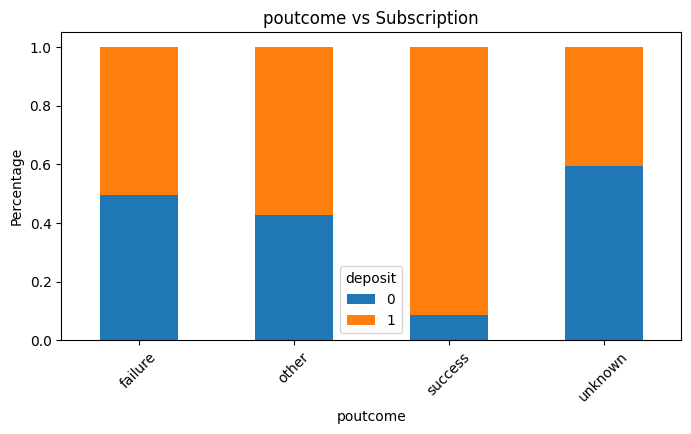

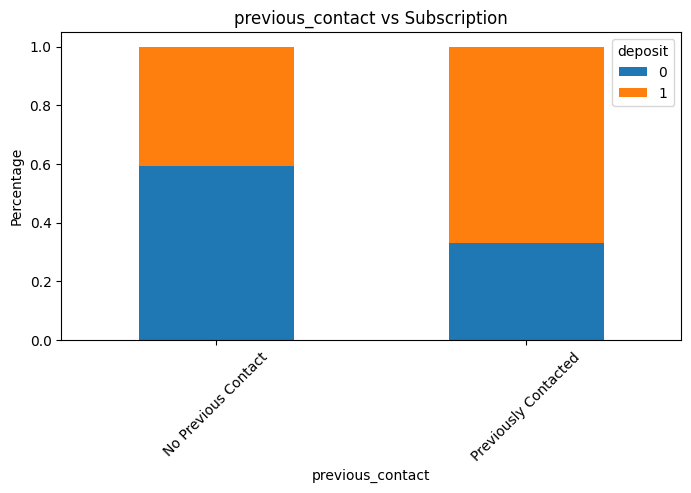

In [27]:
for col in categorical_cols:

    conversion = pd.crosstab(
        df[col],
        df['deposit'],
        normalize='index'
    )

    conversion.plot(
        kind='bar',
        stacked=True,
        figsize=(8,4)
    )

    plt.title(
        f'{col} vs Subscription'
    )

    plt.ylabel(
        'Percentage'
    )

    plt.xticks(rotation=45)

    plt.show()

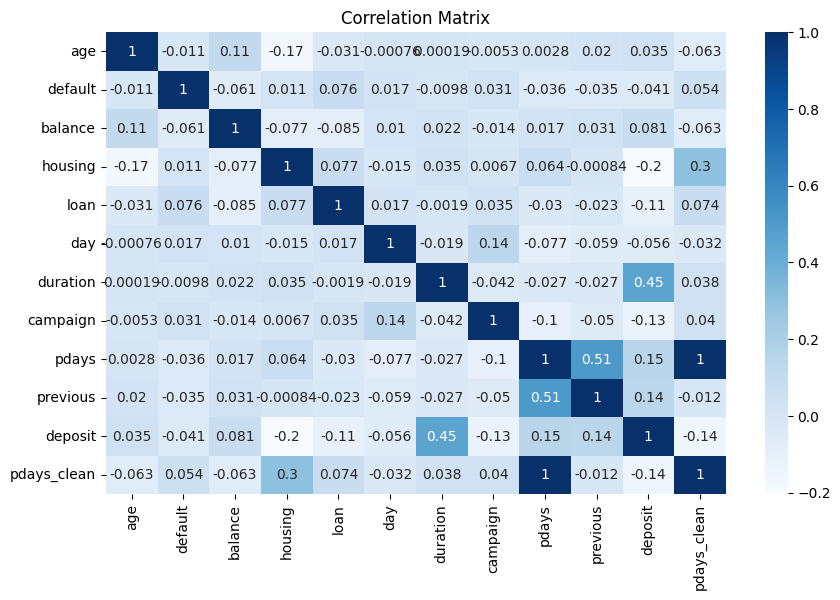

In [37]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(
        numeric_only=True
    ),
    annot=True,
    cmap='Blues'
)

plt.title(
    'Correlation Matrix'
)

plt.show()

In [39]:
round(
    df['deposit']
    .value_counts(normalize=True)
    *100,
    2
)

,proportion
deposit,
0,52.62
1,47.38


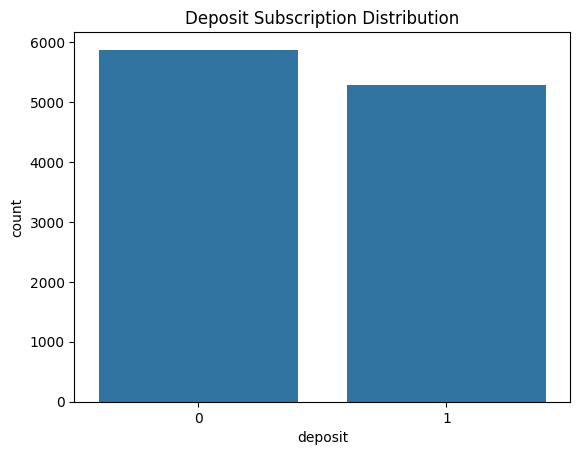

In [40]:
sns.countplot(
    data=df,
    x='deposit'
)

plt.title(
    'Deposit Subscription Distribution'
)

plt.show()

## Insight

1. Customer yang paling responsif untuk deposit adalah mahasiswa yang masih singgle dan masih kuliah

2. Balance yang tinggi cenderung untuk memilih deposit
3. Dari boxplot campain vs subcriptions, terlihat bahwa customer yang sering di kontak, bahkan 63 kali tetap memilih tidak deposit. Sedangkan boxplot yang deposit maksimal ada di 32 kali. Sehingga indikasi bahwa spaming membuat orang tidak mau deposit. Dan winner itu biasanya terjadi ketika di hubungi sekitar 4-6 kali
4. Channel terbaik yang memiliki jumlah deposit terttingi adalah selular
5. Histori campain sebelumnya sangat penting, karena dari grafik poutcame vs subcription, terlihat kalau orang yang banyak deposit adalah dia yang sukses mengikuti campaing sebelumnya
6. Variabel sttaistik yang paling penting: marital, educations, balance, campain, channel, dan poutcame